# Conv+GRU (raw waveform) vs. SPD-RNN (covariance sequence) — Subject 1

Loads `results.json` written by `trainConvGru.ipynb`. The SPD-RNN numbers are the paper's published Subject 1 values
(gowda.pdf, Tables 10/11, mean ± std over 10 seeds). They were not rerun here.

**Epoch budget differs:** Conv+GRU trains for 500 epochs; the SPD-RNN notebooks use 150. Under max-over-epochs a longer budget can only help,
so the max-over-epochs column favours Conv+GRU. Final-epoch accuracy is not inflated by the extra epochs.
Training is deterministic per seed, so the best test accuracy within the first 150 epochs is exactly what a 150-epoch run would give;
that column is the matched-budget comparison.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("results.json") as f:
    results = json.load(f)
configs = results["configs"]

# Subject 1 SPD-RNN, gowda.pdf Tables 10 (audible = Voiced) / 11 (silent = Unvoiced): (mean, std)
spdRnnPaper = {
    "allPhonemes_Voiced": (0.651, 0.030),
    "allPhonemes_Unvoiced": (0.574, 0.014),
    "allWords_Voiced": (0.788, 0.029),
    "allWords_Unvoiced": (0.669, 0.055),
}
spdRnnParams = {"allPhonemes": 146.8e3, "allWords": 146.6e3}  # hand-computed in the plan

In [2]:
rows = []
matchedEpochs = 150
print(f"{'Task / manner':<24}{'chance':>8}{'SPD-RNN (paper)':>18}{'max ≤150 ep':>17}{'Conv+GRU max-epoch':>22}{'Conv+GRU final-epoch':>22}{'diff (max)':>12}{'best epoch (median, range)':>30}")
for configName, config in configs.items():
    maxTestAccuracies = np.array([r["maxTestAccuracy"] for r in config["runs"]])
    finalTestAccuracies = np.array([r["finalTestAccuracy"] for r in config["runs"]])
    maxTestAccuraciesMatched = np.array([max(r["testAccuracyByEpoch"][:matchedEpochs]) for r in config["runs"]])
    bestEpochs = np.array([r["bestEpoch"] for r in config["runs"]])
    paperMean, paperStd = spdRnnPaper[configName]
    print(f"{configName:<24}{1 / config['numberClasses']:>8.3f}{paperMean:>11.3f} ± {paperStd:.3f}"
          f"{maxTestAccuraciesMatched.mean():>10.3f} ± {maxTestAccuraciesMatched.std():.3f}"
          f"{maxTestAccuracies.mean():>15.3f} ± {maxTestAccuracies.std():.3f}"
          f"{finalTestAccuracies.mean():>15.3f} ± {finalTestAccuracies.std():.3f}"
          f"{maxTestAccuracies.mean() - paperMean:>+12.3f}"
          f"{np.median(bestEpochs):>18.0f} ({bestEpochs.min()}-{bestEpochs.max()})")
    rows.append((configName, paperMean, paperStd, maxTestAccuracies, finalTestAccuracies, maxTestAccuraciesMatched))

Task / manner             chance   SPD-RNN (paper)      max ≤150 ep    Conv+GRU max-epoch  Conv+GRU final-epoch  diff (max)    best epoch (median, range)
allPhonemes_Voiced         0.026      0.651 ± 0.030     0.545 ± 0.033          0.598 ± 0.043          0.547 ± 0.051      -0.053               311 (184-495)
allPhonemes_Unvoiced       0.026      0.574 ± 0.014     0.545 ± 0.027          0.589 ± 0.020          0.525 ± 0.042      +0.015               374 (317-472)
allWords_Voiced            0.028      0.788 ± 0.029     0.739 ± 0.043          0.816 ± 0.029          0.765 ± 0.041      +0.028               410 (315-496)
allWords_Unvoiced          0.028      0.669 ± 0.055     0.634 ± 0.039          0.678 ± 0.036          0.626 ± 0.036      +0.009               343 (117-480)


In [3]:
print("Parameter counts:")
for configName, config in configs.items():
    print(f"  {configName:<22} Conv+GRU {config['numParams']:>7,}   SPD-RNN ≈{spdRnnParams[config['task']]:,.0f}")

# Binomial standard error of one accuracy estimate on this test set
for configName, paperMean, *_ in rows:
    n = configs[configName]["numberTestSamples"]
    print(f"  {configName:<22} n_test={n}, binomial SE at p={paperMean:.2f}: ±{np.sqrt(paperMean * (1 - paperMean) / n):.3f}")

Parameter counts:
  allPhonemes_Voiced     Conv+GRU  45,054   SPD-RNN ≈146,800
  allPhonemes_Unvoiced   Conv+GRU  45,054   SPD-RNN ≈146,800
  allWords_Voiced        Conv+GRU  44,924   SPD-RNN ≈146,600
  allWords_Unvoiced      Conv+GRU  44,924   SPD-RNN ≈146,600
  allPhonemes_Voiced     n_test=152, binomial SE at p=0.65: ±0.039
  allPhonemes_Unvoiced   n_test=152, binomial SE at p=0.57: ±0.040
  allWords_Voiced        n_test=144, binomial SE at p=0.79: ±0.034
  allWords_Unvoiced      n_test=144, binomial SE at p=0.67: ±0.039


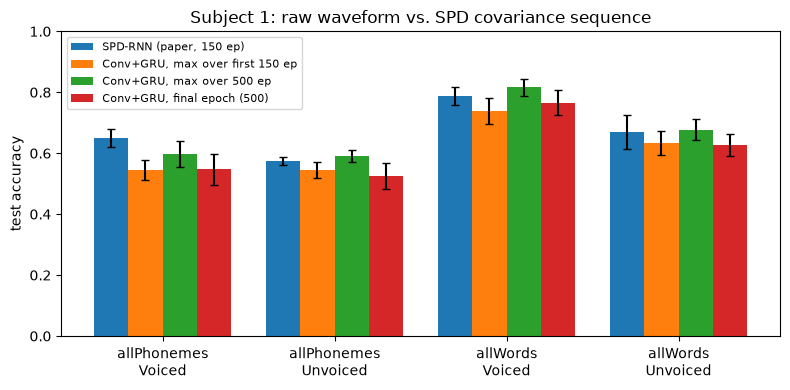

In [4]:
fig, ax = plt.subplots(figsize = (8, 4))
x = np.arange(len(rows))
w = 0.2
ax.bar(x - 1.5 * w, [r[1] for r in rows], w, yerr = [r[2] for r in rows], capsize = 3, label = "SPD-RNN (paper, 150 ep)")
ax.bar(x - 0.5 * w, [r[5].mean() for r in rows], w, yerr = [r[5].std() for r in rows], capsize = 3, label = "Conv+GRU, max over first 150 ep")
ax.bar(x + 0.5 * w, [r[3].mean() for r in rows], w, yerr = [r[3].std() for r in rows], capsize = 3, label = "Conv+GRU, max over 500 ep")
ax.bar(x + 1.5 * w, [r[4].mean() for r in rows], w, yerr = [r[4].std() for r in rows], capsize = 3, label = "Conv+GRU, final epoch (500)")
ax.set_xticks(x, [r[0].replace("_", "\n") for r in rows])
ax.set_ylabel("test accuracy")
ax.set_ylim(0, 1)
ax.legend(loc = "upper left", fontsize = 8)
ax.set_title("Subject 1: raw waveform vs. SPD covariance sequence")
plt.tight_layout()
plt.show()

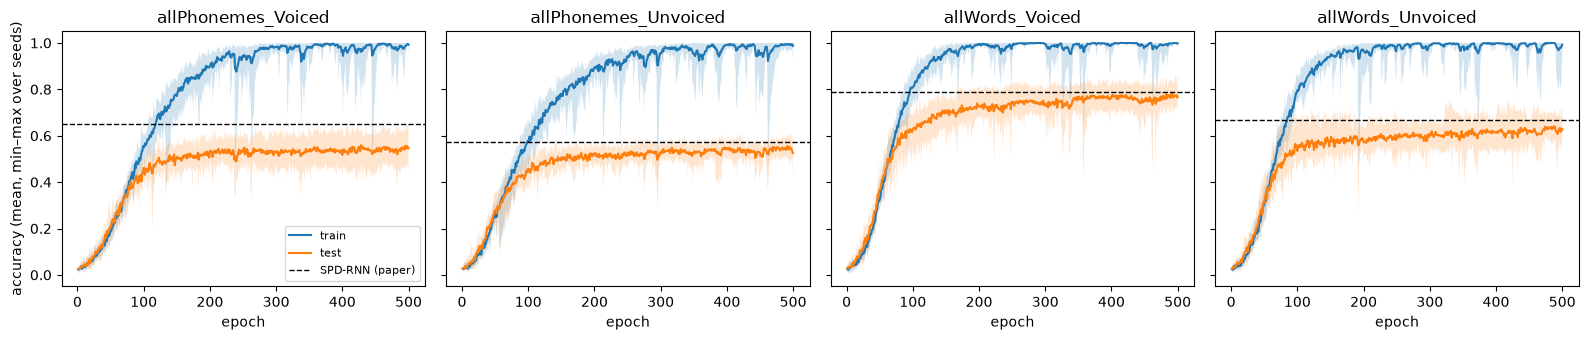

In [5]:
fig, axes = plt.subplots(1, len(configs), figsize = (16, 3.5), sharey = True)
for ax, (configName, config) in zip(axes, configs.items()):
    testByEpoch = np.array([r["testAccuracyByEpoch"] for r in config["runs"]])
    trainByEpoch = np.array([r["trainAccuracyByEpoch"] for r in config["runs"]])
    epochs = np.arange(1, testByEpoch.shape[1] + 1)
    for curves, label in [(trainByEpoch, "train"), (testByEpoch, "test")]:
        ax.plot(epochs, curves.mean(0), label = label)
        ax.fill_between(epochs, curves.min(0), curves.max(0), alpha = 0.2)
    ax.axhline(spdRnnPaper[configName][0], color = "k", ls = "--", lw = 1, label = "SPD-RNN (paper)")
    ax.set_title(configName)
    ax.set_xlabel("epoch")
axes[0].set_ylabel("accuracy (mean, min–max over seeds)")
axes[0].legend(fontsize = 8)
plt.tight_layout()
plt.show()

**Caveats**
- *Max over epochs* is the protocol the repo uses: it keeps the best test accuracy seen across epochs, so it selects on the test set. We copy it only so the numbers are comparable to the paper's; *final epoch* is the honest number.
- With 152/144 test samples and ~65% accuracy, one estimate has a binomial SE of ≈±0.04, and the paper's seed std reaches 0.055. Gaps under ~0.08 are not evidence of a real difference.
- The ± only covers the seed (weight init and shuffle order). The split is fixed, so the held-out trials are never resampled and the ± understates the true uncertainty.
- Representation: each window gives Conv+GRU 40 learned-band powers wᵢᵀCwᵢ and no cross terms wᵢᵀCwⱼ, while the SPD-RNN sees the whole projected 20×20 covariance.